## 1. Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import h5py  
import seaborn as sns
from scipy.special import betaincinv
import scipy.stats as stats


from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata.utils import Cutout2D
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck13, z_at_value, LambdaCDM
from astropy.table import Table
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)
cosmo = Planck13

import pdb
 
import torch
from typing import Optional, Tuple, Union
from torch import Tensor

import pickle
from operator import itemgetter

import os
import sys
sys.path.append(r"C:\Users\usuario\Documents\TFG\florah\src")

from florah.models.rnn_model.rnn_generator import DataModule 

from tqdm import tqdm

In [2]:
def build_roots_optimized(cosmos_cat, mass_bin, nsamples=100, zbins=[0, 0.5, 1], sample_fraction=0.3):
    """
    Optimized version of build_roots.
    Generates initial pairs of galaxies (root -> progenitor candidate), to initialize trees
    """
    
    # ---------------------------------------------------------
    # 1. Prepare data pools
    # ---------------------------------------------------------
    
    # Pool A: Roots (galaxies w redshift between zbins[0] y zbins[1], and mass in mass_bin)
    mask_roots = (
        (cosmos_cat['zpdf_med'] > zbins[0]) & 
        (cosmos_cat['zpdf_med'] < zbins[1]) & 
        (cosmos_cat['mass_CIGALE'] > mass_bin[0]) & 
        (cosmos_cat['mass_CIGALE'] < mass_bin[1])
    )
    pool_roots = cosmos_cat[mask_roots].copy()
    
    # Pool B: Choose progenitor candidates (galaxies w redshift between zbins[1] y zbins[2])
    # Note: We will filter mass later, because it will depend on each root's mass.
    mask_candidates = (
        (cosmos_cat['zpdf_med'] > zbins[1]) & 
        (cosmos_cat['zpdf_med'] < zbins[2])
    )
    pool_candidates = cosmos_cat[mask_candidates].copy()
    
    # If unable to find any galaxy (weird), return empty
    if pool_roots.empty or pool_candidates.empty:
        print("Advertencia: No se encontraron galaxias suficientes en los rangos de Z o Masa.")
        empty_out = {'x': [], 't': [], 'ra': [], 'dec': [], 'sersic': [], 'bovert': [], 'morphology': [], 'id': []}
        return empty_out, 0, []

    # ---------------------------------------------------------
    # 2. Root selection (w nsamples)
    # ---------------------------------------------------------
    if len(pool_roots) < nsamples:
        # If theres less roots in pool than nsamples, will take all but shuffled
        pool_roots = pool_roots.sample(frac=1)
    else:
        # If theres more, we will take only a number nsamples of roots
        pool_roots = pool_roots.sample(n=nsamples)
        
    n_roots = len(pool_roots)
    
    # ---------------------------------------------------------
    # 3. EXTRACCIÓN A NUMPY (VELOCIDAD MÁXIMA)
    # ---------------------------------------------------------
    # Convert DataFrames to dictionary of arrays for easy access
    # Roots
    r_mass = pool_roots['mass_CIGALE'].values
    r_sfr  = pool_roots['sfr_CIGALE'].values
    r_rad  = pool_roots['log_radius_kpc'].values
    r_z    = pool_roots['zpdf_med'].values
    r_ra   = pool_roots['ra'].values
    r_dec  = pool_roots['dec'].values
    r_ser  = pool_roots['sersic'].values
    r_bov  = pool_roots['bovert'].values
    r_mor  = pool_roots['morphology'].values
    r_id   = pool_roots['id'].values

    # Candidates
    c_mass = pool_candidates['mass_CIGALE'].values
    c_sfr  = pool_candidates['sfr_CIGALE'].values
    c_rad  = pool_candidates['log_radius_kpc'].values
    c_z    = pool_candidates['zpdf_med'].values
    c_ra   = pool_candidates['ra'].values
    c_dec  = pool_candidates['dec'].values
    c_sersic = pool_candidates['sersic'].values
    c_bovert = pool_candidates['bovert'].values
    c_morph = pool_candidates['morphology'].values
    c_id   = pool_candidates['id'].values

    # Store results in a list
    out = {k: [] for k in ['x', 't', 'ra', 'dec', 'sersic', 'bovert', 'morphology', 'id']}
    len_sel2_vec = []
    
    total_pairs = 0

    # ---------------------------------------------------------
    # 4. Main loop (iterate over each root)
    # ---------------------------------------------------------
    for i in range(n_roots):
        
        # Mass of current root
        current_mass = r_mass[i]
        
        # FILTER: Find candidates that fulfill mass condition
        # Condition: mass root - 1.5 < mass candidato < mass_root + 0.5
        mask_matches = (c_mass > (current_mass - 1.5)) & (c_mass < (current_mass + 0.5))
        
        # Index of those candidates that fulfill condition
        match_indices = np.where(mask_matches)[0]
        n_matches = len(match_indices)
        
        # FILTER: Sampling a fraction of those candidates (by default sample_fraction=0.03)
        if n_matches > 0:
            n_sample = int(n_matches * sample_fraction)
            
            if n_sample > 0:
                chosen_indices = np.random.choice(match_indices, size=n_sample, replace=False)
                
                # Create pairs (root -> candidate)
                # Iterate over the chosen candidates to build pairs
                for idx in chosen_indices:
                    # ROOTS
                    row0_x = [r_mass[i], r_rad[i], r_sfr[i]]
                    row0_t = [1.0 / (1.0 + r_z[i])]
                    row0_ra = [r_ra[i]]
                    row0_dec = [r_dec[i]]
                    row0_ser = [r_ser[i]]
                    row0_bov = [r_bov[i]]
                    row0_mor = [r_mor[i]]
                    row0_id = [r_id[i]]
                    
                    # Candidates
                    row1_x = [c_mass[idx], c_rad[idx], c_sfr[idx]]
                    row1_t = [1.0 / (1.0 + c_z[idx])]
                    row1_ra = [c_ra[idx]]
                    row1_dec = [c_dec[idx]]
                    row1_ser = [c_sersic[idx]]
                    row1_bov = [c_bovert[idx]]
                    row1_mor = [c_morph[idx]]
                    row1_id = [c_id[idx]]
                    
                    # vstack to create arrays of shape (2, N)
                    out['x'].append(np.array([row0_x, row1_x], dtype=np.float32))
                    out['t'].append(np.array([row0_t, row1_t], dtype=np.float32)) # Shape (2,1)
                    out['ra'].append(np.array([row0_ra, row1_ra], dtype=np.float32))
                    out['dec'].append(np.array([row0_dec, row1_dec], dtype=np.float32))
                    out['sersic'].append(np.array([row0_ser, row1_ser], dtype=np.float32))
                    out['bovert'].append(np.array([row0_bov, row1_bov], dtype=np.float32))
                    out['morphology'].append(np.array([row0_mor, row1_mor], dtype=np.float32))
                    out['id'].append(np.array([row0_id, row1_id], dtype=np.float32))
                    
                    total_pairs += 1
            
            len_sel2_vec.append(n_sample) # Store how many galaxies were sampled in each iteration
        else:
            len_sel2_vec.append(0)

    
    return out, n_roots, len_sel2_vec

In [3]:
def build_features_optimized(cosmos_cat, zbin, node_features, sample_fraction=0.003):
    """
    Optimized version of build_features.
    We find progenitors candidates in next zbin for a given galaxy with node_features
    """
    
    # 1. Filter: Galaxies within zbin
    mask_z = (cosmos_cat['zpdf_med'] > zbin[0]) & (cosmos_cat['zpdf_med'] < zbin[1])
    cosmos_slice = cosmos_cat[mask_z].copy()
    
    if cosmos_slice.empty:
        print("Did not find any galaxies in zbin specified.")
        # Return empty
        return {k: [] for k in node_features}, 0, [0]*len(node_features['x'])

    # Extract candidate columns to arrays
    c_mass = cosmos_slice['mass_CIGALE'].values
    c_sfr = cosmos_slice['sfr_CIGALE'].values
    c_rad = cosmos_slice['log_radius_kpc'].values
    c_z = cosmos_slice['zpdf_med'].values
    c_ra = cosmos_slice['ra'].values
    c_dec = cosmos_slice['dec'].values
    c_sersic = cosmos_slice['sersic'].values
    c_bovert = cosmos_slice['bovert'].values
    c_morph = cosmos_slice['morphology'].values
    c_id = cosmos_slice['id'].values

    # Dictionary to store output
    out = {k: [] for k in ['x', 't', 'ra', 'dec', 'sersic', 'bovert', 'morphology', 'id']}
    sel2_len_vec = [] # Aquí guardaremos el tamaño REAL de los hijos generados
    
    # Descendant data (anterior zbin)
    ids_in = node_features['id']
    xs_in = node_features['x']
    ts_in = node_features['t']
    ras_in = node_features['ra']
    decs_in = node_features['dec']
    sersics_in = node_features['sersic']
    boverts_in = node_features['bovert']
    morphs_in = node_features['morphology']
    
    n_chunks = len(xs_in)

    # 2. Main loop
    for i in range(n_chunks):
        
        mass_last = xs_in[i][-1, 0]
        
        # FILTER: Find candidates that fulfill mass condition
        # Condition: mass root - 1.5 < mass candidato < mass_root + 1.5
        mass_mask = np.abs(c_mass - mass_last) < 1.5
        candidate_indices = np.where(mass_mask)[0]
        n_candidates = len(candidate_indices)
        
        actual_prog_count = 0 
        
        # FILTER: Sampling a fraction of those candidates (by default sample_fraction=0.03)
        if n_candidates > 0:
            size_sample = int(n_candidates * sample_fraction)
            
            if size_sample > 0:
                # Choose index
                chosen_indices = np.random.choice(candidate_indices, size=size_sample, replace=False)
                actual_prog_count = len(chosen_indices)
                
                # Prepare descendant data (galaxy in anterior zbin)
                p_x = xs_in[i]
                p_t = ts_in[i]
                p_ra = ras_in[i]
                p_dec = decs_in[i]
                p_ser = sersics_in[i]
                p_bov = boverts_in[i]
                p_mor = morphs_in[i]
                p_id = ids_in[i]

                # Build branches
                for idx in chosen_indices:
                    new_row_x = np.array([c_mass[idx], c_rad[idx], c_sfr[idx]], dtype=np.float32)
                    new_row_t = np.array([1.0 / (1.0 + c_z[idx])], dtype=np.float32)
                    
                    new_row_ra = np.array([c_ra[idx]], dtype=np.float32)
                    new_row_dec = np.array([c_dec[idx]], dtype=np.float32)
                    new_row_ser = np.array([c_sersic[idx]], dtype=np.float32)
                    new_row_bov = np.array([c_bovert[idx]], dtype=np.float32)
                    new_row_mor = np.array([c_morph[idx]], dtype=np.float32)
                    new_row_id = np.array([c_id[idx]], dtype=np.float32)

                    out['x'].append(np.vstack([p_x, new_row_x]))
                    out['t'].append(np.vstack([p_t, new_row_t]))
                    out['ra'].append(np.vstack([p_ra, new_row_ra]))
                    out['dec'].append(np.vstack([p_dec, new_row_dec]))
                    out['sersic'].append(np.vstack([p_ser, new_row_ser]))
                    out['bovert'].append(np.vstack([p_bov, new_row_bov]))
                    out['morphology'].append(np.vstack([p_mor, new_row_mor]))
                    out['id'].append(np.vstack([p_id, new_row_id]))
        
        sel2_len_vec.append(actual_prog_count)

    return out, n_chunks, sel2_len_vec

In [4]:
def log_likelihood_obs_optimized(
        model: torch.nn.Module, 
        batch: Tuple[Tensor],
        to_numpy: bool = True,
        device: str = None
    ) -> Union[Tensor, np.ndarray]:
    """
    Calculate log-likelihood
    
    Evaluate a batch of trees generated previously to determine how likely are they according to
    trained model.

    Parameters
    ----------
    model : torch.nn.Module
        Recurrent model 
    batch : Tuple[Tensor]
        Data converted to tensor for the model

    to_numpy : bool, opcional
        If True, converts result from PyTorch tensor to NumPy array. (Default: True)
    device : str, opcional
        Device where to execute ('cpu' or 'cuda'). If None, will try to use GPU is available

    Returns
    -------
    lp : Union[Tensor, np.ndarray]
        Vector with log-likelihood values for each sequence evaluated.
    """
    
    # 1. Choose device (GPU vs CPU)
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        
    model = model.to(device)

    # Move data to same device as model
    # (If model is in GPU and data is not, PyTorch fails)
    if isinstance(batch, (tuple, list)):
        batch = tuple(b.to(device) if isinstance(b, torch.Tensor) else b for b in batch)
    elif isinstance(batch, dict):
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
    elif isinstance(batch, torch.Tensor):
        batch = batch.to(device)

    # 2. Optimized evaluation
    with torch.no_grad():
        lp = model.log_prob(batch, return_context=False)

    # 3. Convert to NumPy if solicited
    if to_numpy:
        # We use .cpu() first in case tensor was in gpu
        lp = lp.cpu().detach().numpy()

    return lp

In [5]:
def get_maxlike_descendant_final(l_numpy, node_features, num_chunks, chunk_size):
    """
    Optimized and final version of get_maxlike_descendant
    Choose progenitor with max likelihood 
    """
    
    # 1. Safety Check - Making sure l_numpy has same size as chunk_size
    total_hijos = np.sum(chunk_size)
    total_probs = len(l_numpy)
    

    # 1. DETERMINAR LA LONGITUD DE LA SECUENCIA
    # Si tenemos 25372 probs para 12686 hijos, seq_len es 2.
    if total_hijos > 0:
        seq_len = total_probs // total_hijos
        
        # 2. EXTRAER SOLO LA PROBABILIDAD FINAL DE CADA SECUENCIA
        # l_numpy viene como [P_hijo1_paso1, P_hijo1_paso2, P_hijo2_paso1, P_hijo2_paso2...]
        # Queremos los índices: seq_len - 1, (2*seq_len) - 1, etc.
        indices_finales = np.arange(total_hijos) * seq_len + (seq_len - 1)
        l_numpy_filtrado = l_numpy[indices_finales]
    else:
        l_numpy_filtrado = l_numpy

    # 3. VECTORIZACIÓN PARA ENCONTRAR EL MEJOR HIJO
    parent_ids = np.repeat(np.arange(num_chunks), chunk_size)
    
    # Create temporal DataFrame
    df = pd.DataFrame({
        'likelihood': l_numpy_filtrado,
        'parent_id': parent_ids,
        'global_index': np.arange(len(l_numpy_filtrado))
    })
    
    # Find the global index of max likelihood for each progenitor
    # idxmax gives us index for DF where max is
    best_indices = df.loc[df.groupby('parent_id')['likelihood'].idxmax(), 'global_index'].values
    best_indices.sort()

    # 3. Data extraction
    keys_to_extract = ['x', 't', 'ra', 'dec', 'sersic', 'bovert', 'morphology', 'id']
    node_features_updated = {}

    for key in keys_to_extract:
        original_list = node_features[key]
        # Selecting winning indices
        selected_items = [original_list[i] for i in best_indices]
        node_features_updated[key] = selected_items

    return node_features_updated

## 2. Load data and model

In [6]:
# Load the trained model from a checkpoint file
checkpoint_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\last-v1.ckpt"  # Specify the path to your checkpoint file
loaded_model = DataModule.load_from_checkpoint(checkpoint_path,map_location='cpu', weights_only=False)


# Set the model to evaluation mode (important if you have dropout or batch normalization layers)
loaded_model.eval()

DataModule(
  (model): RecurrentMAF(
    (embedding_net): Identity()
    (rnn): ModuleList(
      (0): GRU(5, 128, batch_first=True)
      (1-3): 3 x GRU(128, 128, batch_first=True)
    )
    (maf_blocks): Flow(
      (_transform): CompositeTransform(
        (_transforms): ModuleList(
          (0): CompositeTransform(
            (_transforms): ModuleList(
              (0-3): 4 x CompositeTransform(
                (_transforms): ModuleList(
                  (0): MaskedAffineAutoregressiveTransform(
                    (autoregressive_net): MADE(
                      (initial_layer): MaskedLinear(in_features=3, out_features=128, bias=True)
                      (context_layer): Linear(in_features=128, out_features=128, bias=True)
                      (blocks): ModuleList(
                        (0-1): 2 x MaskedFeedforwardBlock(
                          (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
                          (line

In [31]:
cosmos_data_path = "C:\\Users\\usuario\\Documents\\TFG\\florah_training_SFR\\"
cosmos_cat = pd.read_csv(cosmos_data_path+"COSMOSWeb_Laura_processed_SFH.csv") # Data from COSMOS-WEB, converted from .fits to .csv in florah_eval_SFR.ipynb

In the next sections we need to choose between running the algorithm that gives us progenitor-descendant relations locally or in deimos. 
Note that paths for both these options are different, due to keeping separated runs from deimos and from my local machine.

#### Run inference algorithm in deimos

In [8]:
dir = "fraction_1_massbin_higher" # change to the dir containing especific run you want to plot
dir = "fraction_1_fixed" # change to the dir containing especific run you want to plot

nfm_data_path = rf"C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\deimos\{dir}\node_features_morphology\\" #path to deimos runs
datos1_data_path = rf"C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\deimos\{dir}\datos1\\"
datos2_data_path = rf"C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\deimos\{dir}\datos2\\"
plots_path = rf"C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\deimos\{dir}\plots\\"

### Upload data

In [9]:
mass_bin = [[9.8, 10], [10, 10.2], [10.2, 10.4], [10.4, 10.6], [10.6, 10.8], [10.8, 11], [11, 12]]
node_features = {}

for m_bin in tqdm(mass_bin):
    file_name = f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl'
    file_path = os.path.join(nfm_data_path, file_name)
    
    with open(file_path, 'rb') as infile:
        data = pickle.load(infile)
        
        # If node_features is empty, initialize it with the keys from the first file
        if not node_features:
            for key in data.keys():
                node_features[key] = []
                
                
        # Append the data for each key
        for key in data.keys():
            # .extend() adds the elements of the new list to the end of the existing list
            node_features[key].extend(list(data[key])) 


100%|██████████| 7/7 [00:00<00:00, 631.24it/s]


In [10]:
# Store data for finding galaxy images in catalog
for i in range(len(node_features['x'])):
    df = pd.DataFrame({
        'id': node_features['id'][i][:, 0],
        # 'x_mass': node_features['x'][i][:, 0],  # Assuming x_mass is the first column of x
        # 'x_size': node_features['x'][i][:, 1],  # Assuming x_size is the second column of x
        # 'x_SFR': node_features['x'][i][:, 2],  # Assuming x_sfr is the second column of x
        # 't': node_features['t'][i][:, 0],
        'ra': node_features['ra'][i][:, 0],
        'dec': node_features['dec'][i][:, 0],
        # 'sersic': node_features['sersic'][i][:, 0],
        # 'bovert': node_features['bovert'][i][:, 0],
        # 'morphology': node_features['morphology'][i][:, 0]
    })

    # Get the values for constructing the file name
    ra_val = node_features['ra'][i][0][0]
    dec_val = node_features['dec'][i][0][0]
    root_id = int(node_features['id'][i][:, 0][0])
    
    # Construct the file name
    file_name = f"COSMOS_{root_id}.csv"

    # Save the DataFrame as a CSV file
    df.to_csv(datos1_data_path+file_name, index=False)


I will store every root ID

In [84]:
nf_root_ids = []
for i in range(len(node_features['id'])):
    nf_root_ids.append(int(node_features['id'][i][:, 0][0]))

# Convert the large list to a set for fast O(1) lookups
cosmos_set = set(cosmos_cat['id'])

# Keep IDs from nf_root_ids only if they aren't in the cosmos_set
root_to_plot = [i for i in nf_root_ids if i in cosmos_set]
print('ids', root_to_plot)


ids [450847, 597391, 123102, 768357, 131823, 648996, 17550, 758802, 513732, 179675, 336825, 518203, 63681, 6133, 316563, 522211, 167146, 428119, 714273, 6607, 314349, 543284, 178413, 525843, 130405, 505728, 690100, 206945, 247227, 688347, 518693, 212603, 483413, 200733, 691311, 132889, 137269, 444308, 729411, 295693, 198110, 443615, 60018, 678159, 430462, 675525, 510905, 19938, 79720, 320911, 424984, 176477, 717052, 522362, 88690, 316667, 763175, 118510, 530819, 599866, 278446, 736714, 526734, 60214, 530766, 515845, 624418, 583536, 627491, 600730, 201909, 446760, 575504, 677831, 314677, 140559, 479270, 159139, 484303, 513042, 676074, 749487, 501819, 315704, 170001, 400469, 62367, 253275, 5018, 5029, 707876, 295209, 373637, 751746, 22935, 365327, 606216, 117978, 476148, 585924, 557554, 6635, 319394, 351702, 236147, 619914, 27203, 368104, 22262, 517310, 249633, 93291, 508653, 711119, 677140, 552574, 122592, 230897, 428588, 514269, 358274, 158183, 672083, 236951, 598711, 232600, 622166, 6

In [32]:
print(node_features.keys())
print(node_features['id'][0])
mask = [i for i in cosmos_set if i == node_features['id'][0][:, 0][0]]
print(cosmos_cat['id'][mask])

print(type(node_features))
print(cosmos_cat.keys())

dict_keys(['x', 't', 'ra', 'dec', 'sersic', 'bovert', 'morphology', 'id'])
[[450847.]
 [755130.]
 [718832.]
 [551357.]
 [501974.]
 [581509.]
 [417161.]
 [ 53820.]]
450847    593586
Name: id, dtype: int64
<class 'dict'>
Index(['id', 'radius_sersic', 'ra', 'dec', 'sersic', 'zpdf_med', 'sfr_raw',
       'mass_raw', 'morphology', 'bovert', 'mass_CIGALE', 'sfr_CIGALE',
       'log_radius_kpc', 'time', 'time_err', 'sfr', 'sfr_err', 'sfh_int',
       'sfh_int_err', 'zfinal', 'mabs_nuv', 'mabs_j', 'mabs_r'],
      dtype='str')


Añadiendo los datos de COSMOS a node features.

In [35]:
# 1. Standardize the ID types
# Your node_features IDs look like floats (450847.). 
# Ensure the DataFrame 'id' column is also of type float so they match perfectly.
cosmos_cat.columns = cosmos_cat.columns.str.strip()

# 2. Make sure your lookup table is explicitly created from cosmos_cat!
df_lookup = cosmos_cat.set_index('id')

# 3. Define which new features you want to bring into your dictionary
features_to_extract = ['mabs_nuv', 'mabs_j', 'mabs_r'] # Add any others you need

# Initialize empty lists in your dictionary for the new features
for feat in features_to_extract:
    node_features[feat] = []

# 4. Loop through each galaxy's assembly history
for history_ids in node_features['id']:
    
    # Flatten the [[id1], [id2]] structure to a 1D array: [id1, id2]
    ids_1d = np.array(history_ids).flatten()
    
    # 5. Look up the data for these specific IDs
    # .reindex() is great here because it preserves the exact order of your IDs.
    # If a specific ID from the dictionary isn't in the DataFrame, it will safely insert a NaN.
    matched_data = df_lookup.reindex(ids_1d)
    
    # 6. Extract the columns and append them back to the dictionary
    for feat in features_to_extract:
        # Get the values and reshape them back to (N, 1) to match the shape of the IDs
        feat_values = matched_data[feat].values.reshape(-1, 1)
        node_features[feat].append(feat_values)

In [104]:
# 1. Asegúrate de que las columnas sean numéricas para poder operar con ellas.
# (Es una buena práctica por si Pandas las cargó como texto originalmente)
mabs_nuv = cosmos_cat['mabs_nuv'].astype(float)
mabs_r = cosmos_cat['mabs_r'].astype(float)
mabs_j = cosmos_cat['mabs_j'].astype(float)

# 2. Aplica tu condición a todo el DataFrame a la vez (usando & para arrays)
is_quiescent = (mabs_nuv - mabs_r > 3 * (mabs_r - mabs_j)) & (mabs_nuv - mabs_r > 3.1)

# 3. Cuenta los resultados
conteo = is_quiescent.value_counts()

# 4. Imprime los resultados de forma clara
# Usamos .get(True, 0) para evitar errores si por casualidad el número fuera cero
num_quiescent = conteo.get(True, 0)
num_star_forming = conteo.get(False, 0)

print("--- Resumen del Catálogo COSMOS ---")
print(f"Galaxias Quiescentes (Rojas): {num_quiescent}")
print(f"Galaxias Star-Forming (Verdes): {num_star_forming}")
print(f"Total de galaxias evaluadas: {len(cosmos_cat)}")

--- Resumen del Catálogo COSMOS ---
Galaxias Quiescentes (Rojas): 134476
Galaxias Star-Forming (Verdes): 454060
Total de galaxias evaluadas: 588536


Which galaxies are both in nf_root_ids and in CIGALE?

In [12]:
# cigale_data_path = r'C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\id_sfh_3\\'

# root_to_plot = []

# for root in nf_root_ids:
#     file_name = f'CIGALE_{str(root)}_sfh.csv'
#     file_path = os.path.join(cigale_data_path, file_name)
#     try:
#         cigale_df = pd.read_csv(file_path)
#         root_to_plot.append(int(cigale_df['id'][0]))
#     except FileNotFoundError:
#         print(f'Galaxia {root} no se encontró en CIGALE')
#         continue
# print(len(root_to_plot))


In [13]:
# 1. TFG STYLE CONFIGURATION
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

# 2. CATEGORICAL COLOR MAPPING
# Keys must match the exact strings in your file_val list
sim_colors = {
    'EAGLE': '#37C2E0',  # Blue
    'Simba': '#E09A28',  # Mustard
    'TNG': '#E03471'     # Pink
}

colors_tfg = {
    'Blue': '#37C2E0',  # Blue
    'Mustard': '#E09A28',  # Mustard
    'Pink': '#E03471',     # Pink
    'Turq': '#33E0BB'
}

## 3. Data analysis

### 3.1 Mass, SFR and Size evolution

    WIP: Distinguish between quiescent or not

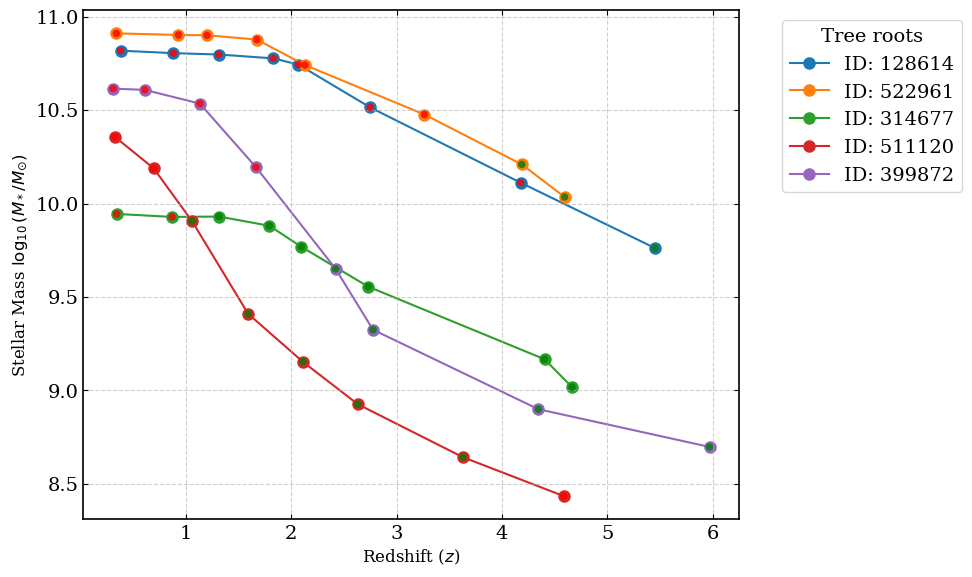

In [122]:
def plot_mass_evolution(node_features, num_trees):
    plt.figure(figsize=(10, 6))
    
    # Tomamos una muestra de árboles
    n_total = len(node_features['x'])
    indices = np.random.choice(nf_root_ids, min(num_trees, n_total), replace=False)

    for obj_id in indices:
        for i in range(len(node_features['id'])):        
        # Safest way to check if ID is in the numpy array
            if np.any(node_features['id'][i][:, 0][0] == obj_id):
                # Extraemos masa y factor de escala
                # Usamos .flatten() para asegurar que sean arrays de 1D
                masas = np.array(node_features['x'][i]).flatten()
                a = np.array(node_features['t'][i]).flatten()
        
                # Si la masa tiene más columnas (ej. masa, radio, SFR), 
                # nos aseguramos de coger solo la primera (masa)
                if masas.ndim > 1 or len(masas) > len(a):
                    masas = np.array(node_features['x'][i])[:, 0]

                z = (1.0 / a) - 1.0
        
                # Extraemos el ID de forma segura para el label
                galaxy_id = int(node_features['id'][i][:, 0][0])
                
                mabs_nuv = node_features['mabs_nuv'][i].flatten()
                mabs_r = node_features['mabs_r'][i].flatten()
                mabs_j = node_features['mabs_j'][i].flatten()

                # Calculate if galaxy is active or passive (quiescent)
                cond = (mabs_nuv - mabs_r > 3* (mabs_r - mabs_j)) & (mabs_nuv - mabs_r > 3.1)
                colores_puntos = np.atleast_1d(np.where(cond, 'red', 'green'))


                plt.plot(z, masas, marker='o', linestyle='-', markersize=8, zorder=1, label=f'ID: {galaxy_id}')
                scatter = plt.scatter(z, masas, c=colores_puntos, s=30, edgecolors='none', alpha=0.8, zorder=2)


    # Estética de la gráfica
    plt.xlabel('Redshift ($z$)', fontsize=12)
    plt.ylabel(r'Stellar Mass $\log_{10}(M_* / M_{\odot})$', fontsize=12)
    # plt.title('Stellar mass evolution', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Tree roots", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(plots_path+'log_mass_evolution_branches.png')
    plt.show()
    

# Llamada a la función
plot_mass_evolution(node_features, 5)

In [ ]:
def plot_radius_evolution(node_features, num_trees=20):
    plt.figure(figsize=(10, 6))
    
    # Tomamos una muestra de árboles
    n_total = len(node_features['x'])
    indices = np.random.choice(n_total, min(num_trees, n_total), replace=False)

    for i in indices:
        # Extraemos datos
        # Usamos .flatten() para asegurar que sean arrays de 1D
        a = np.array(node_features['t'][i]).flatten()
        re = np.array(node_features['x'][i])[:, 1]
        z = (1.0 / a) - 1.0
        
        # Extraemos el ID de forma segura para el label
        try:
            # Intentamos sacar el primer elemento del ID y convertirlo a entero
            galaxy_id = int(np.array(node_features['id'][i]).flatten()[0])
        except:
            galaxy_id = i # Si falla, usamos el índice de la lista

        plt.plot(z, re, marker='o', linestyle='-', alpha=0.8, label=f'ID: {galaxy_id}')

    # Estética de la gráfica
    plt.xlabel('Redshift ($z$)', fontsize=12)
    plt.ylabel(r'Galaxy radius $\log_{10}(z \cdot R_e)$', fontsize=12)
    plt.title('Galaxy radius evolution evolution', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Tree roots", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    #plt.savefig(plots_path+'log_radius_evolution_branches.png')
    plt.show()

# Llamada a la función
plot_radius_evolution(node_features,10)


In [ ]:
def plot_sfr_evolution(node_features, num_trees):
    plt.figure(figsize=(10, 6))

    # Tomamos una muestra de árboles
    n_total = len(node_features['x'])
    indices = np.random.choice(nf_root_ids, min(num_trees, n_total), replace=False)



    for obj_id in indices:
        for i in range(len(node_features['id'])):        
        # Safest way to check if ID is in the numpy array
            if np.any(node_features['id'][i][:, 0][0] == obj_id):
                # Extraemos masa y factor de escala
                # Usamos .flatten() para asegurar que sean arrays de 1D

                a = np.array(node_features['t'][i]).flatten()
                sfr = np.array(node_features['x'][i])[:, 2]
                z = (1.0 / a) - 1.0
        
                # Extraemos el ID de forma segura para el label
                galaxy_id = int(node_features['id'][i][:, 0][0])

                all_galaxy_id = node_features['id'][i]
                all_galaxy_ra = node_features['ra'][i]
                all_galaxy_dec = node_features['dec'][i]



                plt.plot(z, sfr, marker='o', linestyle='-', alpha=0.8, label=f'ID: {galaxy_id}')


    # Estética de la gráfica
    plt.xlabel('Redshift ($z$)', fontsize=12)
    plt.ylabel(r'Stellar formation rate $\log_{10}(SFR)$', fontsize=12)
    plt.title('Galaxy stellar formation rate evolution', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Tree roots", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    #plt.savefig(plots_path+'log_sfr_evolution_branches.png')
    plt.show()

# Llamada a la función
plot_sfr_evolution(node_features,10)

In [ ]:
def plot_morph_evolution(node_features, num_trees):
    plt.figure(figsize=(10, 6))

    # Tomamos una muestra de árboles
    n_total = len(node_features['x'])
    indices = np.random.choice(nf_root_ids, min(num_trees, n_total), replace=False)

    # clean data 
    node_features['morphology'] = [np.where(x == 999999., 4, x) for x in node_features['morphology']]

    for obj_id in indices:
        for i in range(len(node_features['id'])):        
        # Safest way to check if ID is in the numpy array
            if np.any(node_features['id'][i][:, 0][0] == obj_id):
                # Extraemos masa y factor de escala
                # Usamos .flatten() para asegurar que sean arrays de 1D

                a = np.array(node_features['t'][i]).flatten()
                sfr = np.array(node_features['morphology'][i])
                z = (1.0 / a) - 1.0
                
                indices4 = np.where(sfr == 4)[0]
                sfr_notype = sfr[indices4]
                z_notype = z[indices4]
                
            
                    # Extraemos el ID de forma segura para el label
                galaxy_id = int(node_features['id'][i][:, 0][0])

                all_galaxy_id = node_features['id'][i]
                all_galaxy_ra = node_features['ra'][i]
                all_galaxy_dec = node_features['dec'][i]



                plt.plot(z, sfr, marker='o', linestyle='-', alpha=0.8, label=f'ID: {galaxy_id}')
                plt.scatter(z_notype, sfr_notype, s = 50, color ='red', zorder=5)
                


    # Estética de la gráfica
    plt.yticks([0, 1, 2, 3, 4], ['E', 'S', 'I', 'B+D', 'NoType'])
    plt.xlabel('Redshift ($z$)', fontsize=12)
    plt.ylabel(r'Stellar formation rate $\log_{10}(SFR)$', fontsize=12)
    plt.title('Galaxy stellar formation rate evolution', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Tree roots", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    #plt.savefig(plots_path+'morph_evolution_branches.png')
    plt.show()

# Llamada a la función
plot_morph_evolution(node_features,2)
print(node_features['morphology'][i])

### 3.2 PICS - Mass, SFR and Size evolution

In [ ]:
# Roots para las que tenemos fotitos:
roots_pics =[130567, 175080, 315646, 508710, 525621, 666286, 734273, 755470]


In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
def plot_mass_evolution_pics(node_features, num_trees):
    plt.figure(figsize=(20, 10))
    
    # Tomamos una muestra de árboles
    n_total = len(node_features['x'])
    indices = np.random.choice(roots_pics, min(num_trees, n_total), replace=False)

    for obj_id in indices:
        for i in range(len(node_features['id'])):        
        # Safest way to check if ID is in the numpy array
            if np.any(node_features['id'][i][:, 0][0] == obj_id):
                # Extraemos masa y factor de escala
                # Usamos .flatten() para asegurar que sean arrays de 1D
                masas = np.array(node_features['x'][i]).flatten()
                a = np.array(node_features['t'][i]).flatten()
        
                # Si la masa tiene más columnas (ej. masa, radio, SFR), 
                # nos aseguramos de coger solo la primera (masa)
                if masas.ndim > 1 or len(masas) > len(a):
                    masas = np.array(node_features['x'][i])[:, 0]

                z = (1.0 / a) - 1.0
        
                # Extraemos el ID de forma segura para el label
                galaxy_id = int(node_features['id'][i][:, 0][0])
                print('Hola:', galaxy_id, obj_id)
                
                all_galaxy_id = node_features['id'][i]

                plt.plot(z, masas, marker='o', linestyle='-', alpha=0.8, label=f'ID: {galaxy_id}')
                # buscamos las imagenes
                img_dir = rf"C:\Users\usuario\Documents\TFG\galaxy_pics\composed_pics\COSMOS_{obj_id}\\"
                for g, galaxy in enumerate(all_galaxy_id):
                    galaxy = int(galaxy[0])
                    img = plt.imread(img_dir+f'ID_{galaxy}.jpg')
                    imagebox = OffsetImage(img, zoom=0.1)
                    ab = AnnotationBbox(imagebox, xy=(z[g], masas[g]), frameon=False)
                    plt.gca().add_artist(ab)
            else:
                print('No tengo esas fotitos')




    # Estética de la gráfica
    plt.xlabel('Redshift ($z$)', fontsize=12)
    plt.ylabel(r'Stellar Mass $\log_{10}(M_* / M_{\odot})$', fontsize=12)
    plt.title(f'Stellar mass evolution for root {indices}', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Tree roots", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    #plt.savefig(plots_path+'log_mass_evolution_branches.png')
    plt.show()
    

# Llamada a la función
plot_mass_evolution_pics(node_features, 1)

### 3.3 Evolution for mass bins

In [ ]:
plt.figure(figsize=[10, 6])

all_sfrs = []
all_redshifts = []

for i in range(50):  # Assuming you have 20 entries based on your example
    redshifts = 1 / np.array(node_features['t'][i]) - 1
    sfr = np.array(node_features['x'][i][:, 2])
    plt.plot(redshifts, sfr, color='gray', alpha=0.3)

    all_redshifts.extend(redshifts)
    all_sfrs.extend(sfr)

# Make sure the data is in the correct numpy array format
all_redshifts_np = np.squeeze(np.array(all_redshifts))
all_sfrs_np = np.array(all_sfrs)

valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
filtered_redshifts = all_redshifts_np[valid_data_mask]
filtered_sfrs = all_sfrs_np[valid_data_mask]

# Verify shapes
print("Shapes:", all_redshifts_np.shape, all_sfrs_np.shape)

# Binning the data
bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.plot(bin_centers, bin_means, color='red')
plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color='red', alpha=0.3)


# Estética de la gráfica
plt.xlabel('Redshift ($z$)', fontsize=12)
plt.ylabel(r'Stellar formation rate $\log_{10}(SFR)$', fontsize=12)
plt.title('Galaxy stellar formation rate evolution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(plots_path+'log_sfr_evolution_modified.png')
plt.show()



In [ ]:
# Plot example for every mass bin
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 


plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features_massbin = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features_massbin['t'])):
        redshifts = 1 / np.array(node_features_massbin['t'][i]) - 1
        sfr = np.array(node_features_massbin['x'][i][:, 2])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha
        all_redshifts.extend(redshifts)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=r"$ \log_{10} (M_* / M_\odot):$"+f" ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)


# Estética de la gráfica
plt.xlabel('Redshift ($z$)', fontsize=12)
plt.ylabel(r'Stellar formation rate $\log_{10}(SFR)$', fontsize=12)
plt.legend(loc='lower right')
plt.title('Galaxy stellar formation rate evolution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(plots_path+'log_sfr_ev_massbin.png')
plt.show()





In [ ]:
# Define your redshift bins and mass bins
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features_massbin = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []
   

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features_massbin['t'])):
        redshifts = 1 / np.array(node_features_massbin['t'][i]) - 1
        t = np.array(node_features_massbin['t'][i])
        cosmic_times = Planck13.age(redshifts)
        sfr = 10**np.array(node_features_massbin['x'][i][:, 2])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=r"$ \log_{10} (M_* / M_\odot):$"+f" ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot



# Estética de la gráfica
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=12)
plt.ylabel(r'SFR ($M_\odot \cdot yr^{-1}$)', fontsize=12)
plt.legend(loc='upper left')
plt.title('Galaxy stellar formation rate evolution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(plots_path+'sfr_ev_massbin.png')
plt.show()



In [ ]:
# Define your redshift bins and mass bins

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features_massbin = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features_massbin['t'])):
        redshifts = 1 / np.array(node_features_massbin['t'][i]) - 1
        sfr = np.array(node_features_massbin['x'][i][:, 0])
        
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_edges = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3.5, 4.5, 6])
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=r"$ \log_{10} (M_* / M_\odot):$"+f" ({m_bin[0]}-{m_bin[1]})",lw=2, marker='.')
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)



# Estética de la gráfica
plt.xlabel('Redshift ($z$)', fontsize=12)
plt.ylabel(r'Stellar Mass $\log_{10}(M_* / M_{\odot})$', fontsize=12)
plt.legend(loc='lower left')
plt.title('Stellar mass evolution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(plots_path+'log_mass_ev_massbin.png')
plt.show()

In [ ]:
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features_massbin = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features_massbin['t'])):
        redshifts = 1 / np.array(node_features_massbin['t'][i]) - 1
        sfr = np.array(node_features_massbin['sersic'][i])
        
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=r"$ \log_{10} (M_* / M_\odot):$"+f" ({m_bin[0]}-{m_bin[1]})",lw=2, marker='.')
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Redshift ($z$)', fontsize=12)
plt.ylabel('Sersic index', fontsize=12)
plt.legend(loc='upper right')
plt.title('Sersic index evolution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(plots_path+'sersic_idx_growth_massbin.png')
plt.show()


In [ ]:
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features_massbin = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features_massbin['t'])):
        redshifts = 1 / np.array(node_features_massbin['t'][i]) - 1
        cosmic_times = Planck13.age(redshifts)
        sfr = np.array(node_features_massbin['x'][i][:, 0])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=r"$ \log_{10} (M_* / M_\odot):$"+f" ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic time ($Gyrs$)', fontsize=12)
plt.ylabel(r'Stellar mass $\log_{10}(M_* / M_{\odot})$', fontsize=12)
plt.legend(loc='lower right')




plt.title('Stellar mass evolution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(plots_path+'log_mass_ev_cosmicyears_massbin.png')
plt.show()



In [ ]:
# Define your redshift bins and mass bins
nbins=10
#colors = ['blue', 'green', 'purple', 'orange']  # Adjust or add more colors for each mass bin

colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features_massbin = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features_massbin['t'])):
        redshifts = 1 / np.array(node_features_massbin['t'][i]) - 1
        cosmic_times = Planck13.age(redshifts)
        sfr = np.array(10**node_features_massbin['x'][i][:, 0]/10**node_features_massbin['x'][i][0, 0])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=r"$ \log_{10} (M_* / M_\odot):$"+f" ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic time ($Gyrs$)', fontsize=20)
plt.ylabel('$M_*(t)/M_*(t_H)$', fontsize=20)
plt.legend(loc='lower right')
plt.savefig(plots_path+'mass-t_mass-th_cosmicyears_massbin.png')
plt.show()


In [ ]:
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features_massbin = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features_massbin['t'])):
        redshifts = 1 / np.array(node_features_massbin['t'][i]) - 1
        cosmic_times = Planck13.age(redshifts)
        sfr = np.array(node_features_massbin['sersic'][i])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=r"$ \log_{10} (M_* / M_\odot):$"+f" ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('Sersic Index', fontsize=20)
plt.legend(loc='lower right')
plt.savefig(plots_path+'sersic_cosmicyears_massbin.png')
plt.show()


In [ ]:
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features_massbin = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features_massbin['t'])):
        redshifts = 1 / np.array(node_features_massbin['t'][i]) - 1
        sfr = np.array(node_features_massbin['bovert'][i])
        #plt.plot(redshifts, sfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(redshifts)
        all_sfrs.extend(sfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=r"$ \log_{10} (M_* / M_\odot):$"+f" ({m_bin[0]}-{m_bin[1]})",lw=2, marker='.')
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.title('B/T evolution mass bins', fontsize=14)
plt.xlabel('Redshift', fontsize=20)
plt.ylabel('B/T', fontsize=20)
plt.legend(loc='lower right')
plt.savefig(plots_path+'bt_massbin.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[12, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path + f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features_massbin = pickle.load(infile)


    # Iterates through the list, and uses np.where to clean each array inside it
    node_features['morphology'] = [np.where(x == 999999., np.nan, x) for x in node_features['morphology']]
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features_massbin['t'])):
        redshifts = 1 / np.array(node_features_massbin['t'][i]) - 1
        cosmic_times = Planck13.age(redshifts).value  # Make sure to extract value if it's a Quantity
        morphology = np.array(node_features_massbin['morphology'][i])
        for q in range(len(morphology)):
            if morphology[q] > 3:
                print(morphology[q])
                morphology[q] = 4
            else:
                continue
        #print(node_features['morphology'][i], node_features['id'][i])

        all_redshifts.extend(cosmic_times)
        all_sfrs.extend(morphology)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.squeeze(np.array(all_sfrs))

    # Filtering valid data
    valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np[valid_data_mask]
    filtered_sfrs = all_sfrs_np[valid_data_mask]

    # Binning the data
    bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=r"$ \log_{10} (M_* / M_\odot):$"+f" ({m_bin[0]}-{m_bin[1]})", lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Replace numerical y-axis values with labels
plt.yticks([0, 1, 2, 3], ['E', 'S', 'I', 'B+D'])

# Finalizing the plot
plt.axhline(y=0, color='gray', linestyle='--')
plt.axhline(y=1, color='gray', linestyle='--')
plt.axhline(y=2, color='gray', linestyle='--')
plt.axhline(y=3, color='gray', linestyle='--')
plt.xlabel('Cosmic Time [$Gyr$]', fontsize=20)
plt.ylabel('Morphology', fontsize=20)
plt.legend(loc='best')
plt.tight_layout
plt.savefig(plots_path+'morphology_evolution_cosmicyears.png')
plt.show()


In [ ]:
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features_massbin = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features_massbin['t'])):
        redshifts = 1 / np.array(node_features_massbin['t'][i]) - 1
        sfr = np.array(node_features_massbin['x'][i][:, 2])
        mstar = np.array(node_features_massbin['x'][i][:, 0])
        ssfr = np.log10(10**np.array(node_features_massbin['x'][i][:, 2])/10**np.array(node_features_massbin['x'][i][:, 0]))
        plt.plot(mstar, ssfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(mstar)
        all_sfrs.extend(ssfr)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    #valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np
    filtered_sfrs = all_sfrs_np

    # Binning the data
    bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=r"$ \log_{10} (M_* / M_\odot):$"+f" ({m_bin[0]}-{m_bin[1]})",lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.title(r'$\log$ SFR vs. $\log_{10}(M_* / M_{\odot})$', fontsize=14)
plt.xlabel(r'$\log_{10}(M_* / M_{\odot})$', fontsize=20)
plt.ylabel(r'$ SFR / M_*$', fontsize=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(plots_path+'log_sfr_log_mass_combined.png')
plt.show()


In [ ]:
# Define your redshift bins and mass bins
colors = ['red', 'orange', 'green', 'blue', 'purple', 'hotpink', 'brown']  # Adjust or add more colors for each mass bin 

plt.figure(figsize=[8, 8])
plt.tick_params(axis='both', which='major', labelsize=20)

# Loop through each mass bin and corresponding color
for m_bin, color in zip(mass_bin, colors):
    # Load node_features for the current mass bin
    with open(nfm_data_path+f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl', 'rb') as infile:
        node_features_massbin = pickle.load(infile)
        
    all_sfrs = []
    all_redshifts = []

    # Assuming 'n_chunks' is the total number of entries for node_features['t']
    for i in range(len(node_features_massbin['t'])):
        redshifts = 1 / np.array(node_features_massbin['t'][i]) - 1
        sfr = np.array(node_features_massbin['x'][i][:, 2])
        re = np.array(node_features_massbin['x'][i][:, 1])
        mstar = np.array(node_features_massbin['x'][i][:, 0])
        ssfr = np.log10(10**np.array(node_features_massbin['x'][i][:, 2])/10**np.array(node_features_massbin['x'][i][:, 0]))
        #plt.plot(mstar, ssfr, color=color, alpha=0.2)  # Use the same color for individual lines, with some alpha

        all_redshifts.extend(mstar)
        all_sfrs.extend(re)

    # Processing for binned statistics
    all_redshifts_np = np.squeeze(np.array(all_redshifts))
    all_sfrs_np = np.array(all_sfrs)

    # Filtering valid data
    #valid_data_mask = ~np.isnan(all_redshifts_np) & ~np.isnan(all_sfrs_np)
    filtered_redshifts = all_redshifts_np
    filtered_sfrs = all_sfrs_np

    # Binning the data
    bin_edges = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
    bin_means, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='mean', bins=bin_edges)
    bin_stds, _, _ = stats.binned_statistic(filtered_redshifts, filtered_sfrs, statistic='std', bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Plotting mean and std deviation
    plt.plot(bin_centers, bin_means, color=color, label=rf'$\log_{{10}} (M_* / M_\odot)$: ({m_bin[0]}-{m_bin[1]})',lw=4)
    plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, color=color, alpha=0.3)

# Finalizing the plot
plt.title(r'$\log R_e$ vs. $\log_{10}(M_* / M_{\odot})$', fontsize=14)
plt.xlabel(r'$\log_{{10}} (M_* / M_{\odot})$', fontsize=20)
plt.ylabel(r'$\log R_e$', fontsize=20)
plt.legend(loc='lower right')
plt.savefig(plots_path+'log_re_log_mass_combined.png')
plt.show()


In [ ]:
file_list = []


# Generate the list of file names based on node_features['id']
for m_bin in mass_bin:
    # Load node_features for the current mass bin
    with open(os.path.join(nfm_data_path, f'node_features_morphology{m_bin[0]}_{m_bin[1]}.pkl'), 'rb') as infile:
        node_features_massbin = pickle.load(infile)
        
    for i in range(len(node_features_massbin['x'])):
        id_val = node_features_massbin['id'][i][0, 0]  # Ensure this is how your ID is structured
        file_name = f"{id_val}_SFH.fits"
        file_list.append(file_name)

# Generate a single string of file names separated by spaces for the tar command
file_list_str = ' '.join([datos2_data_path + file for file in file_list])

# Create the command to generate a tarball
tar_command = f"tar -czvf collected_files.tar.gz {file_list_str}"

# Write the command to a shell script file
script_file_name = "create_tarball.sh"
with open(nfm_data_path+script_file_name, 'w') as script_file:
    script_file.write("#!/bin/bash\n")
    script_file.write(tar_command + "\n")

# Make the script executable
os.chmod(nfm_data_path+script_file_name, 0o755)

print(f"The tar command has been saved in {script_file_name}")


### 3.4 graficas chiquitas de nuevo (creo que es redundante)


In [ ]:
for i in range(len(node_features['x'])):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,2]))

plt.xlabel('$\log_{10}(M_* / M_{\odot})$',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)
plt.tight_layout()

plt.savefig(plots_path+'logsfr_logmass.png')


In [ ]:
for i in range(len(node_features['x'])):
    ssfr = np.log10(10**np.array(node_features['x'][i][:,2])/10**np.array(node_features['x'][i][:,0]))
    plt.plot(np.array(node_features['x'][i][:,0]),ssfr)

plt.xlabel('$ M_*/M_\odot$',fontsize=20)

plt.ylabel('$SFR$',fontsize=20)

plt.savefig(plots_path+'sfr_mass_combined.png')

In [ ]:
for i in range(50):
    plt.plot(1/ np.array(node_features['t'][i]) - 1 ,10**np.array(node_features['x'][i][:,0])/10**np.array(node_features['x'][i][0,0]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log (M_* / M_{{0*}}) $',fontsize=20)


print(node_features['ra'][11][0][0])
print(node_features['dec'][11][0])

plt.savefig(plots_path+'mass_growth2.png')

In [ ]:
for i in range(10):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,1]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log R_e$',fontsize=20)    

In [ ]:
for i in range(10):
    plt.plot(1/ np.array(node_features['t'][i]) - 1,np.array(node_features['x'][i][:,2]))

plt.xlabel('redshift',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)      

In [ ]:
for i in range(20):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,2]))

plt.xlabel('$\log_{10}(M_* / M_{\odot})$',fontsize=20)

plt.ylabel('$\log SFR$',fontsize=20)    

In [ ]:
for i in range(20):
    plt.plot(np.array(node_features['x'][i][:,0]),np.array(node_features['x'][i][:,1]))


plt.xlabel('$\log_{10}(M_* / M_{\odot})$',fontsize=20)

plt.ylabel('$\log Re$',fontsize=20)   

## 4. Comparison between CIGALE and FLORAH

### 4.1 Plotting CIGALE data

First, we will plot some samples in CIGALE to see the general behaviour of the data.

In [ ]:
# Load cigale data
cigale_data_path = r"C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\id_sfh_3\\"
rng = np.random.default_rng(seed=42)
id_to_plot = rng.choice(root_to_plot, size=10, replace=False)


plt.figure(figsize=(12, 10))
colors = plt.cm.Spectral_r(np.linspace(0, 1, len(id_to_plot)))


for color, obj_id in enumerate(id_to_plot):
    # 1. Load CIGALE data
    file_name = f"CIGALE_{str(obj_id)}_sfh.csv" 
    file_path = os.path.join(cigale_data_path, file_name)
    
    try:
        # Read data
        cigale_df = pd.read_csv(file_path)

        cigale_id = cigale_df['id']

        # We clean time data -> From Myr to Gyr
        cigale_time = cigale_df['time'] * 10**(-3)   # Convert to Gyr
        #cigale_time = cigale_time.iloc[::-1] 
        
        cigale_time_err = cigale_df['time_err'] * 10**(-3) # Convert to Gyr

        # Convert to redshift
        lbt_quantity = cigale_time.to_numpy() * u.Gyr
        cigale_z = z_at_value(cosmo.lookback_time, lbt_quantity)

    
        # We clean sfr data -> Denormalize and error propagation
        cigale_sfr = cigale_df['sfr'] * cigale_df['sfh_int']
        cigale_sfr_err = cigale_df['sfr_err'] * cigale_df['sfh_int'] + cigale_df['sfr'] * cigale_df['sfh_int_err']

        # Log10 on SFR data
        cigale_sfr = np.log10(cigale_sfr)
        cigale_sfr_err = np.log10(cigale_sfr_err)
        
    except FileNotFoundError:
        print(f"Warning: CIGALE file not found for ID {obj_id}. Skipping...")
        continue


    # ---------------------------------------------------------
    # 3. Plot the Comparison
    # ---------------------------------------------------------
    
    # Plot CIGALE data
    plt.plot(cigale_z, cigale_sfr, label=obj_id, marker='o', linewidth=2, color=colors[color])
    plt.errorbar(cigale_time, cigale_sfr, yerr = abs(cigale_sfr_err),marker='o', linestyle=None, linewidth=1,capsize=2, color=colors[color])
    
    
    # Formatting the plot
plt.title(f"Star Formation History (CIGALE)", fontsize=14)
plt.xlabel("Lbt [Gyr]", fontsize=12) 
plt.ylabel(r"log10 Star Formation Rate [$M_{\odot}$/yr]", fontsize=12) 
    

# Add legend and grid
plt.gca().invert_xaxis()
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()

#plt.savefig(plots_path+'CIGALE_examples2.png')

plt.show()

### 4.2 We will plot SFH for each galaxy in root_to_plot

#### 4.2.1 PLOTS

In [ ]:
# Load cigale data
cigale_data_path = r"C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\id_sfh_3\\"
plots_path_comp =rf'C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\deimos\{dir}\plots\comparison\\'

# We select a few IDs from the CIGALE files
id_to_plot = root_to_plot

# last cigale point in age of the universe (gyr)
last_cigale = []


for obj_id in root_to_plot:
    # ---------------------------------------------------------
    # 1. Search for obj_id in node_features
    # ---------------------------------------------------------
    found_in_nodes = False

    for i in range(len(node_features['id'])):        
        if np.any(node_features['id'][i][:, 0][0] == obj_id):

            #---- TIME ----
            scale_factor = node_features['t'][i][:, 0]
            redshifts = (1.0 / scale_factor) - 1.0     # Convert to redshift
            #z_root = redshifts[0]                      # Store for later
            my_time = cosmo.age(redshifts)             # Convert to age of the universe in Gyr


            #---- SFR ----
            my_sfr = node_features['x'][i][:, 2]       # in log10
            

            # Extract params
            my_mass = np.array(node_features['x'][i])[:, 0][0]

            found_in_nodes = True
            break  
            
    if not found_in_nodes:
        #print(f"Warning: ID {obj_id} not found in node_features. Skipping...")
        continue

    # Load CIGALE data
    file_name = f"CIGALE_{str(obj_id)}_sfh.csv" 
    file_path = os.path.join(cigale_data_path, file_name)
    try:
        # Read data
        cigale_df = pd.read_csv(file_path)
        z_root = cigale_df['zpdf_med']
        mabs_nuv = cigale_df['mabs_nuv'][0]
        mabs_r = cigale_df['mabs_r'][0]
        mabs_j = cigale_df['mabs_j'][0]

        # Calculate if galaxy is active or passive (quiescent)
        cond = (mabs_nuv - mabs_r > 3* (mabs_r - mabs_j)) and (mabs_nuv - mabs_r > 3.1)
        quiescent_str = "Yes" if cond else "No"
    

        #---- TIME ----
            # 1. Import data
        cigale_lbt = cigale_df['time'] * 10**(-3)          # Convert to Gyr
        cigale_lbt_err = cigale_df['time_err'] * 10**(-3)   # Convert err to Gyr, and add 1e-6 to avoid error with z_at_value


            # 2. Clean data
        age_root = cosmo.age(z_root)          # Age of universe at redshift of the root in Gyr 
        cigale_time = age_root.value - cigale_lbt   # Calculate age to match that of node_features     
        cigale_time_err = cigale_lbt_err      # Assuming lbt_root does not have error


        cigale_time = cigale_time.to_numpy() 
        cigale_time_err = cigale_time_err.to_numpy()
        last_cigale.append(cigale_time[-1])


        # Calculate redshift - this will take a lot of time, but we will store this calculation for later
        # 1. Feed your cosmic time array to z_at_value (it requires Astropy units)
        cigale_z_quantity = z_at_value(cosmo.age, cigale_time * u.Gyr, zmax=1e8)

        # 2. Extract it back into a pure numpy array if you don't want the unit attached
        cigale_z = cigale_z_quantity.value
        print("Type:", type(cigale_z))
        print("Shape:", np.shape(cigale_z))



        #---- SFR ----
        cigale_sfr = cigale_df['sfr'] 
        cigale_sfr_err = cigale_df['sfr_err'] 
        cigale_sfh_int = cigale_df['sfh_int'] 
        cigale_sfh_int_err = cigale_df['sfh_int_err'] 


        log_cigale_sfr_denorm = np.log10(cigale_sfr * cigale_sfh_int)              # Log10 on SFR data
        log_cigale_sfr_denorm_err = (1/np.log(10)) * (abs(cigale_sfr_err/cigale_sfr) + abs(cigale_sfh_int_err/cigale_sfh_int))


        
    except FileNotFoundError:
        #print(f"Warning: CIGALE file not found for ID {obj_id}. Skipping...")
        continue

    # ---------------------------------------------------------
    # 3. Plot the Comparison
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    
    # Plot your node_features data
    plt.plot(my_time, my_sfr, label='My Data (node_features)', color='red', marker='o', markersize=6, alpha=0.8, linewidth=2)

    # Plot CIGALE data
    plt.plot(cigale_time, log_cigale_sfr_denorm, label='CIGALE SFH', color='blue', marker='o', linestyle='--', linewidth=2)
    plt.errorbar(cigale_time, log_cigale_sfr_denorm, xerr = abs(cigale_time_err), yerr = abs(log_cigale_sfr_denorm_err), linestyle=None, capsize=2)
    plt.fill_between(cigale_time, log_cigale_sfr_denorm+log_cigale_sfr_denorm_err, log_cigale_sfr_denorm-log_cigale_sfr_denorm_err, color='lightblue')
    #plt.errorbar(cigale_time, cigale_sfr, xerr=cigale_time_err, yerr=cigale_sfr_prop_err)
    #plt.errorbar(cigale_time, cigale_sfr, xerr=cigale_time_err, yerr=cigale_sfr_err)
    print(obj_id, cigale_time, cigale_time_err)


    info_text = (f"Log10 Mass of root: {my_mass:.2f}" r"$M_{{ \odot }}$" "\n"
                 f'Quiescent? {quiescent_str}')
    
    
    # Formatting the plot
    plt.title(f"Star Formation History Comparison for COSMOS-WEB ID: {obj_id}", fontsize=14)
    plt.xlabel("Age of Universe [Gyr]", fontsize=12) 
    #plt.xlabel("redshifts z", fontsize=12) 
    plt.ylabel(r"log10 (Star Formation Rate [$M_{\odot}$/yr])", fontsize=12) 
    

    # Adding labels to X axis
    plt.text(cigale_time[-1], -0.08, "Past", color='red', ha='center', 
         transform=plt.gca().get_xaxis_transform())

    plt.text(my_time[0].value, -0.08, "Present", color='blue', ha='center', 
            transform=plt.gca().get_xaxis_transform())


    # Add legend and grid
    plt.gca().invert_xaxis()
    plt.legend(title=info_text, fontsize=11)
    plt.grid(True, which="both", ls="--", alpha=0.4)
    
    plt.tight_layout()

    if cond == True:
        plt.savefig(plots_path_comp+'quiescent\\'+f'CIGALE_FLORAH_{obj_id}.png')
    else:
        plt.savefig(plots_path_comp+'not_quiescent\\'+f'CIGALE_FLORAH_{obj_id}.png')
    plt.show()




#### 4.2.2 HISTOGRAMS

In [ ]:
# Load cigale data
cigale_data_path = r"C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\id_sfh_3\\"
plots_path_comp =rf'C:\Users\usuario\Documents\TFG\likelihood_COSMOS_SFR\deimos\{dir}\plots\histograms\\'

# last cigale point in age of the universe (gyr)
last_cigale = []
cigale_all_time = []

for obj_id in root_to_plot:
    # ---------------------------------------------------------
    # 1. Search for obj_id in node_features
    # ---------------------------------------------------------
    found_in_nodes = False

    for i in range(len(node_features['id'])):        
        if np.any(node_features['id'][i][:, 0][0] == obj_id):

            #---- TIME BIN----
            scale_factor = node_features['t'][i][:, 0]
            redshifts = (1.0 / scale_factor) - 1.0     # Convert to redshift
            #z_root = redshifts[0]                      # Store for later
            zbins = node_features['formation_history_zbins'][i][:-1]
            my_time_bin = cosmo.age(zbins).value        # Convert to age of the universe in Gyr
            my_time = cosmo.age(redshifts)                  # Convert to age of the universe in Gyr

            #---- SFR ----
            my_sfr = node_features['x'][i][:, 2]       # in log10

            # Extract params
            my_mass = np.array(node_features['x'][i])[:, 0][0]

            found_in_nodes = True
            break  
            
    if not found_in_nodes:
        #print(f"Warning: ID {obj_id} not found in node_features. Skipping...")
        continue

    # Load CIGALE data
    file_name = f"CIGALE_{str(obj_id)}_sfh.csv" 
    file_path = os.path.join(cigale_data_path, file_name)
    try:
        # Read data
        cigale_df = pd.read_csv(file_path)
        z_root = cigale_df['zpdf_med']
        print(z_root)
        mabs_nuv = cigale_df['mabs_nuv'][0]
        mabs_r = cigale_df['mabs_r'][0]
        mabs_j = cigale_df['mabs_j'][0]

        # Calculate if galaxy is active or passive (quiescent)
        cond = (mabs_nuv - mabs_r > 3* (mabs_r - mabs_j)) and (mabs_nuv - mabs_r > 3.1)
        quiescent_str = "Yes" if cond else "No"

        #---- TIME ----
            # 1. Import data
        cigale_lbt = cigale_df['time'] * 10**(-3)          # Convert to Gyr
        cigale_lbt_err = cigale_df['time_err'] * 10**(-3)   # Convert err to Gyr, and add 1e-6 to avoid error with z_at_value


            # 2. Clean data
        age_root = cosmo.age(z_root)          # Age of universe at redshift of the root in Gyr 
        cigale_time = age_root.value - cigale_lbt   # Calculate age to match that of node_features     
        cigale_time_err = cigale_lbt_err      # Assuming lbt_root does not have error


        cigale_time = cigale_time.to_numpy() 
        cigale_time_err = cigale_time_err.to_numpy()
        last_cigale.append(cigale_time[-1])
        cigale_all_time.append(cigale_time)




        #---- SFR ----
        cigale_sfr = cigale_df['sfr'] 
        cigale_sfr_err = cigale_df['sfr_err'] 
        cigale_sfh_int = cigale_df['sfh_int'] 
        cigale_sfh_int_err = cigale_df['sfh_int_err'] 


        log_cigale_sfr_denorm = np.log10(cigale_sfr * cigale_sfh_int)              # Log10 on SFR data
        log_cigale_sfr_denorm_err = (1/np.log(10)) * (abs(cigale_sfr_err/cigale_sfr) + abs(cigale_sfh_int_err/cigale_sfh_int))


        
    except FileNotFoundError:
        #print(f"Warning: CIGALE file not found for ID {obj_id}. Skipping...")
        continue

    # ---------------------------------------------------------
    # 3. Plot the Comparison
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))

    # Plot CIGALE data
    plt.step(cigale_time, log_cigale_sfr_denorm, color='blue', where='mid', alpha=0.7)
    plt.fill_between(cigale_time, log_cigale_sfr_denorm+log_cigale_sfr_denorm_err, log_cigale_sfr_denorm-log_cigale_sfr_denorm_err, step='mid', color='lightblue')
    plt.scatter(cigale_time, log_cigale_sfr_denorm, label='CIGALE SFH', color='blue', marker='o', linewidth=2)

    #plt.fill_between(cigale_lbt, log_cigale_sfr_denorm, step="pre", color='lightblue', alpha=0.7, label='Datos CIGALE')
    #plt.errorbar(cigale_lbt, log_cigale_sfr_denorm, xerr = abs(cigale_lbt_err), yerr = abs(log_cigale_sfr_denorm_err), linestyle=None, capsize=2)
    #plt.fill_between(cigale_lbt, log_cigale_sfr_denorm+log_cigale_sfr_denorm_err, log_cigale_sfr_denorm-log_cigale_sfr_denorm_err, color='lightblue')
    

    # Plot your node_features data
    plt.stairs(my_sfr, my_time_bin, fill=False, color='lightcoral', baseline=None)
    plt.scatter(my_time, my_sfr, label='My Data (node_features)', color='red', marker='o', alpha=0.8, linewidth=2)



    info_text = (f"Mass of root: {my_mass:.2f}" r"$M_{{ \odot }}$" "\n"
                 f'Quiescent? {quiescent_str}')
    
    
    # Formatting the plot
    plt.title(f"Star Formation History Comparison for COSMOS-WEB ID: {obj_id}", fontsize=14)
    plt.xlabel("Age of Universe [Gyr]", fontsize=12) 
    #plt.xlabel("redshifts z", fontsize=12) 
    plt.ylabel(r"log10 (Star Formation Rate [$M_{\odot}$/yr])", fontsize=12) 
    

    # Adding labels to X axis
    plt.text(cigale_time[-1], -0.08, "Past", color='red', ha='center', 
         transform=plt.gca().get_xaxis_transform())

    plt.text(13.8, -0.08, "Present", color='blue', ha='center', 
            transform=plt.gca().get_xaxis_transform())

    
    # Add legend and grid
    plt.gca().invert_xaxis()
    plt.legend(title=info_text, fontsize=11)
    plt.grid(True, which="both", ls="--", alpha=0.4)
    
    plt.tight_layout()

    if cond == True:
        plt.savefig(plots_path_comp+'quiescent\\'+f'CIGALE_FLORAH_{obj_id}.png')
    else:
        plt.savefig(plots_path_comp+'not_quiescent\\'+f'CIGALE_FLORAH_{obj_id}.png')
    plt.show()


In [ ]:
media_final = np.mean(cigale_all_time, axis=0)
media_final = cigale_all_time[-1]
print(media_final)
redshifts_finales = [tiempo_a_redshift(t) for t in media_final]
print(redshifts_finales)


In [ ]:
plt.figure(1)
# Convertimos z bins a cosmic time
zbins = np.array([0, 0.5, 1., 1.5, 2, 2.5, 3.5, 4.5, 6])
cosmic_time = cosmo.age(zbins)
print('Zbins de FLORAH en tiempo cosmico', cosmic_time)


## nuevo zbin

zbins = np.array([0, 0.1, 1.5, 3.5, 7, 13.5, 24.5, 44.5, 79, 140])
zbins = np.array([0.1, 0.13, 0.17, 0.22, 0.28, 0.47, 1.5, 30])

#27.64840145  1.03701691  0.57448743  0.43673626 0.38505395 0.3642135  0.3555712  0.35194934  0.35040927 
cosmic_time = cosmo.age(zbins)
print('NUEVOS Zbins de FLORAH en tiempo cosmico', cosmic_time)
plt.scatter(zbins, np.zeros(len(zbins)))


# Convertimos la lista de Series a una matriz y promediamos
media_final = np.mean(cigale_all_time, axis=0)


print('media cosmic time', media_final) ## Esto está en cosmic time -> hay que pasarlo a redshift jeje
def tiempo_a_redshift(tiempo_gyr):
    # z_at_value busca el redshift correspondiente a una edad del universo
    return z_at_value(cosmo.age, tiempo_gyr * u.Gyr)

# Aplicar a todos los valores (puedes usar una lista comprimida)
redshifts_finales = [tiempo_a_redshift(t) for t in media_final]
plt.plot(redshifts_finales, np.ones(9),'.', c='r')


print('Redshift_promedios de cigale', redshifts_finales[::-1])
plt.figure(2)
plt.plot(media_final, np.ones(9),'.', c='r')
plt.plot(cosmic_time, np.zeros(len(zbins)), '.')


plt.show()
